In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                              confusion_matrix, classification_report)

print("Libraries loaded!")


Libraries loaded!


# **Regression Implementation**

In [14]:
#Diabetes dataset - real medical data used to predict disease progression from patient measurements
diabetes = load_diabetes(as_frame=True)
df_reg = diabetes.frame
print("Regression dataset shape:", df_reg.shape)
df_reg.head()



Regression dataset shape: (442, 11)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [18]:
#splitting in trainig and testing data
X = df_reg.iloc[:, :4]
X_train, X_test, y_train, y_test = train_test_split(X, df_reg['target'], test_size=0.2, random_state=42)

In [19]:
# Linear Regression - fits a straight line through the data that best predicts a continuous output (y) from input (X),
# by minimizing the total squared error between predicted and actual values.
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)

print("Linear Regression -> R²:", round(r2_score(y_test, y_pred_lin), 3),
      "| RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_lin)), 2))

Linear Regression -> R²: 0.298 | RMSE: 60.98


In [20]:
# Polynomial Regression - extends linear regression by adding powers of X (X², X³...) so the model can fit curved,
# non-straight-line relationships between input and output
poly = PolynomialFeatures(degree=3)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)
y_pred_poly = poly_reg.predict(X_test_poly)

print("Polynomial Regression -> R²:", round(r2_score(y_test, y_pred_poly), 3),
      "| RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_poly)), 2))


Polynomial Regression -> R²: 0.279 | RMSE: 61.79


In [21]:
# Ridge Regression - linear regression with an added penalty (L2) on large coefficients, which helps prevent
# overfitting by keeping the model's weights small and more stable
ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(X_train, y_train)
y_pred_ridge = ridge_reg.predict(X_test)

# Lasso Regression - similar to Ridge, but uses a different penalty (L1) that can shrink some coefficients to exactly
# zero, effectively performing automatic feature selection
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X_train, y_train)
y_pred_lasso = lasso_reg.predict(X_test)

print("Ridge Regression -> R²:", round(r2_score(y_test, y_pred_ridge), 3))
print("Lasso Regression -> R²:", round(r2_score(y_test, y_pred_lasso), 3))


Ridge Regression -> R²: 0.267
Lasso Regression -> R²: 0.303


# **Classification Functions**


In [8]:
#Breast Cancer dataset - real diagnostic data used to classify tumors as malignant or benign
cancer = load_breast_cancer(as_frame=True)
df_clf = cancer.frame
print("Classification dataset shape:", df_clf.shape)
print("Target classes:", cancer.target_names)
df_clf.head()


Classification dataset shape: (569, 31)
Target classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [25]:
# splitting in training and testing data
X = df_clf.iloc[:, :4]
X_train, X_test, y_train, y_test = train_test_split(X, df_clf['target'], test_size=0.2, random_state=42)

In [24]:
# Feature Scaling - rescaling features to a similar range (mean 0, std 1) so no single feature dominates due to its scale;
# especially important for distance-based models like KNN.
scaler = StandardScaler()
X_train_c_scaled = scaler.fit_transform(X_train_c)
X_test_c_scaled = scaler.transform(X_test_c)

print("Train size:", X_train_c.shape[0], "| Test size:", X_test_c.shape[0])

Train size: 455 | Test size: 114


In [26]:
# Logistic Regression - despite the name, it's a classification algorithm. It takes inputs, applies a weighted sum,
# then squashes the result through a sigmoid function to output a probability between 0 and 1 (e.g. malignant vs benign).
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train_c_scaled, y_train_c)
y_pred_log = log_reg.predict(X_test_c_scaled)

print("Logistic Regression Accuracy:", round(accuracy_score(y_test_c, y_pred_log), 3))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_log, target_names=cancer.target_names))

Logistic Regression Accuracy: 0.982

Classification Report:
               precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [27]:
# KNN (K-Nearest Neighbors) - classifies a new data point by looking at the 'k' closest points in the training data
# and assigning the most common class among those neighbors; no real "training", it just compares distances at prediction time.
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_c_scaled, y_train_c)
y_pred_knn = knn.predict(X_test_c_scaled)

print("KNN Accuracy:", round(accuracy_score(y_test_c, y_pred_knn), 3))
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_knn, target_names=cancer.target_names))


KNN Accuracy: 0.956

Classification Report:
               precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



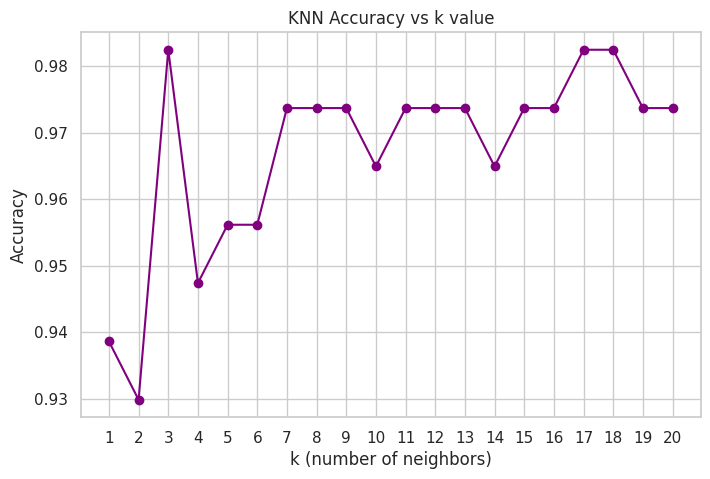

In [11]:
# Demonstrating how accuracy changes with different values of k (hyperparameter tuning intuition)
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_c_scaled, y_train_c)
    acc = accuracy_score(y_test_c, knn_temp.predict(X_test_c_scaled))
    accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', color='purple')
plt.xlabel("k (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs k value")
plt.xticks(k_values)
plt.grid(True)
plt.show()
